## BTSP in a T-maze

* T-maze, largely fixed direction navigation, randomly selecting target arm on each trajectory
* CA3: 40 preset place fields
* CA1: 
  * Hebbian learning + BTSP learning at targeted neurons
  * BTSP learning: long-tailed (pre) Hebbian learning with a high output firing rate considered (occurs at every repeat)
  * (1) 1 cell, receives BTSP signal at a reward location
  * (2) 6 cells, with 4 receiving BTSP signals (reward branch, wrong branch, split and start, respectively) 

Evaluate resulting CA1 neuron place field properties

In [1]:
import copy
from pathlib import Path
import sys
import warnings

from matplotlib import pyplot as plt
import numpy as np
import ratinabox
from tqdm import tqdm

add_paths = [str(Path(".."))]
for add_path in add_paths:
    if add_path not in sys.path:
        sys.path.append(add_path)

from predhpc import agent, env, neurons, run_manager, plot_util, util

In [2]:
ratinabox.stylize_plots()
ratinabox.autosave_plots = False
ratinabox.figure_directory = "figures"

In [3]:
# warnings.filterwarnings("ignore", message="solid 1D boundary", category=UserWarning)
warnings.filterwarnings("ignore", message="invalid value encountered", category=RuntimeWarning)

In [4]:
def learn_2D_btsp(env_params, agent_params, CA3_PC_params, CA1_params, num_rwd=200, max_steps=10000, wei_freq=100, hebbian=False):
    """Run a 1D learning experiment with BTSP learning.

    Args:
        env_params (dict): Parameters for the environment.
        agent_params (dict): Parameters for the agent.
        CA3_PC_params (dict): Parameters for the CA3 place cells.
        CA1_params (dict): Parameters for the CA1 neurons.
        num_rwd (int, optional): Target number of rewards to reach. Defaults to 200.
        max_steps (int, optional): Maximum number of steps to run. Defaults to 10000.
        wei_freq (int, optional): Frequency at which to record weights. Defaults to 100.
        hebbian (bool, optional): Whether to use Hebbian learning. Defaults to False.
    
    Returns:
        Environment, Agent, CA1 neurons, CA3 place cells
    """

    Env = env.TEnv(params=ENV_PARAMS)

    Ag = agent.TAgent(Env, params=AGENT_PARAMS)
    CA3_PCs = ratinabox.PlaceCells(Ag, params=CA3_PC_params)

    CA1_params["input_layers"] = [CA3_PCs]
    CA1s = neurons.BTSPLayer(Ag, params=CA1_params)
    if not hebbian:
        CA1s.set_freeze()
    CA1s.set_btsp_learn()
    
    # run learning
    restarted = False
    CA1_weights = [CA1s.inputs[CA3_PCs.name]["w"].copy()]
    for i in tqdm(range(max_steps)):
        Ag.update(speed_fact=3, drift_to_random_strength_ratio=1)
        CA3_PCs.update()

        # check whether a restart BTSP signal should go out
        btsp_targs = []
        if restarted and CA1s.n > 1:
            btsp_targs = [CA1s.n - 1]

        # check whether a target BTSP signal should go out
        if Ag.reached_target:
            btsp_targs = [0]

        # check for restart
        restarted = Ag.reached_end

        # run update
        CA1s.update(btsp_targs=btsp_targs)
        if not i % wei_freq:
            CA1_weights.append(CA1s.inputs[CA3_PCs.name]["w"].copy())

        if len(Ag.reached_reset_pos) >= num_rwd:
            break
    
    if len(Ag.reached_target_pos) < num_rwd:
        print(f"Only reached the reward {len(Ag.reached_target_pos)} times (target: {num_rwd}).")
    
    Ag.log_trajectory_stats_to_date()
    Ag.log_trajectory_stats_to_date(time=False)
        
#     plot_1D_env_info(Ag, CA3_PCs, CA1s, CA1_weights)

#     plot_time_info(Ag, CA3_PCs, CA1s)
    
    return Env, Ag, CA3_PCs, CA1s

In [5]:
ENV_PARAMS = {
    "prop_width": 0.1,
}

DT = 0.02
AGENT_PARAMS = {
    "dt": 0.02,
    "thigmotaxis": 0.5,
    "speed_mean": 0.16,
    "speed_std": 0.16,
    "reset_tolerance_prop": 1,
}

CA3_PC_PARAMS = {
    "name": "CA3_PCs",
    "n": 40,
    "description": "gaussian_threshold",
    "place_cell_centres": "uniform",
    "min_fr": 0,
    "max_fr": 10,
    "color": "C5",
    "widths": DT * 8,
    "wall_geometry": "line_of_sight", # due to environment shape
}

CA1_PARAMS = {
    "name": "CA1_BTSP",
    "color": "C2",
    "biases": None,
    "init_weights_zero": True,
    "w_init_scale": 0.1, # set fairly small
    "lr": 1e-4,
    "oja": True,
    "btsp_tau": DT * 8,
    "btsp_fr": 5,
    "n": 1
}

In [6]:
Env, Ag, CA3_PCs, CA1s = learn_2D_btsp(
    ENV_PARAMS, 
    AGENT_PARAMS, 
    CA3_PC_PARAMS, 
    CA1_PARAMS, 
    num_rwd=100, 
    max_steps=4000, 
    wei_freq=100, 
    hebbian=False
)

100%|██████████████████████████████████████| 4000/4000 [00:04<00:00, 953.79it/s]

Only reached the reward 4 times (target: 100).
Trajectory lengths (16) to date: 5.00 +/- 0.58 sec each
Trajectory lengths (16) to date: 250.00 +/- 28.79 steps each


In [7]:
import importlib
importlib.reload(plot_util)

<module 'predhpc.plot_util' from '/home/cgillon/Documents/predhpc/scripts/../predhpc/plot_util.py'>

In [8]:
Ag.reached_target_pos
CA1s.history["btsp_events"]

[796, 1563, 3549, 3799]

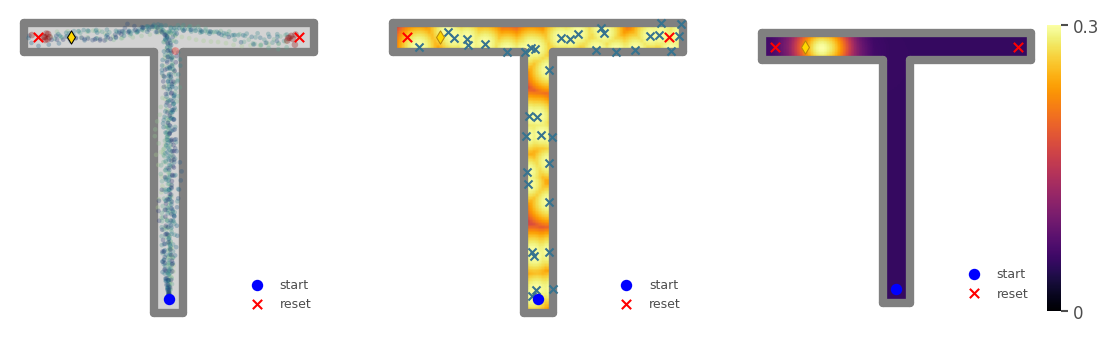

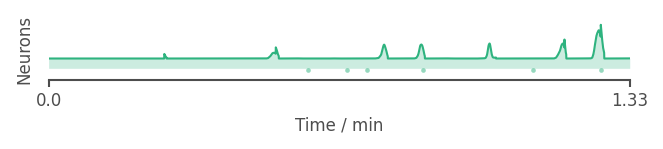

In [12]:
fig, ax = plt.subplots(ncols=3, figsize=(9, 3))
Ag.plot_trajectory(scale_cmap_per=False, ms_2D=5, alpha=0.3, fig=fig, ax=ax[0])

plot_util.plot_overlayed_rate_maps(CA3_PCs, fig=fig, ax=ax[1], method="max", colorbar=False)
CA3_PCs.plot_place_cell_locations(fig=fig, ax=ax[1])
ax[1].scatter(*Ag.target_pos, marker="d", color="gold", s=20, zorder=5, edgecolors="darkgoldenrod", linewidth=0.5)

CA1s.plot_rate_map(fig=fig, ax=ax[2])
ax[2].scatter(*Ag.target_pos, marker="d", color="gold", s=20, zorder=5, edgecolors="darkgoldenrod", linewidth=0.5)

fig, ax = plt.subplots(figsize=(5, 0.5))
CA1s.plot_rate_timeseries(chosen_neurons="all", spikes=True, fig=fig, ax=ax);

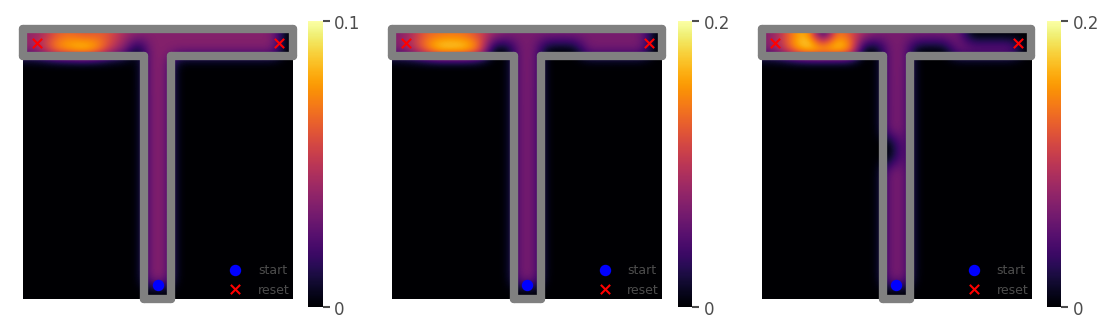

In [10]:
fig, ax = plt.subplots(ncols=3, figsize=(9, 3))
CA1s.plot_rate_map(fig=fig, ax=ax[0], t_start=0, t_stop=20, method="history")
CA1s.plot_rate_map(fig=fig, ax=ax[1], t_start=30, t_stop=50, method="history")
CA1s.plot_rate_map(fig=fig, ax=ax[2], t_start=60, method="history");

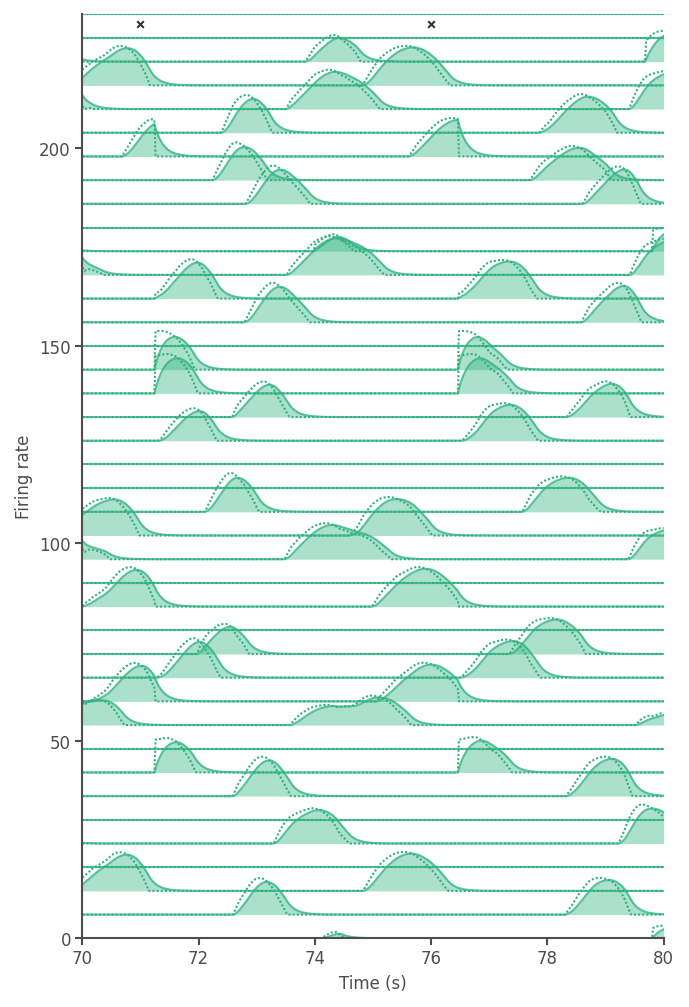

In [11]:
fig, ax = plt.subplots(figsize=(5, 8))
CA1s.plot_btsp_filtered("CA3_PCs", t_start=-10, fig=fig, ax=ax);

### Developments
- BTSP events on the first trajectories (then none later)
- Upgrade to a 2D environment
- Add more signals (e.g., Novelty)
- Expand the network to have an EC layer (i.e., encode more environment features)
- Expand the network to have a DG-like layer (i.e., memory)
- Closing the loop: predictiveness shaping reward/novelty signal